In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
from pathlib import Path
import sys
import pandas as pd
import corner

import cogwheel.likelihood
import cogwheel.data
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, add_derived_quantities

In [3]:
# helper function to get median values
def get_medians(samples, corner_plot):
    medians = {}
    for key in samples.keys():
        medians[key] = corner_plot._get_median_and_central_interval(key)[0]
    return medians

In [4]:
# load samples from event posterior(s)

# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 10 events


In [5]:
def load_posterior_samples(eventname, event_path):
    # find the "earliest" run with posterior samples
    i = 0
    samples = None
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_path, f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1
    if samples is None:
        print(f"no samples found for {eventname}")
        return None, None

    # add derived quantities
    add_derived_quantities(samples)

    # load the posterior samples from the LIGO PE data release
    pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
    data = read(pe_data_fn)
    # get the posterior samples using the IMRPhenomXPHM approximant
    samples_lvk = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]

    return samples, samples_lvk

In [6]:
def plot_p_lensed(samples, eventname=None, return_ax=False, **kwargs):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples['p_lensed'], bins=100,
                               weights=samples['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])
    
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(edges, pdf, c='navy', alpha=0.9, **kwargs)
    ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
    ax.set_xlabel('p_lensed')
    ax.set_xlim(0., 1.)
    ax.set_ylim(0., None)
    
    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)
    val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))
    title_str = "p_lensed" if eventname is None else f"{eventname}: p_lensed"
    ax.set_title(title_str + val_err_str)
    if return_ax:
        return ax

In [7]:
# plot parameters for our cogwheel results:
plot_params = [
    'mchirp',
    'm1',
    'm2',
    'chieff',
    'd_luminosity',
    'ra',
    'dec',
    'p_lensed'
]

In [8]:
# number of resamples
n_resamples = 1000

2026-01-02  00:06:39 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2026-01-02  00:06:39 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.


loaded posterior samples for GW230628_231200 run 1
loaded posterior samples for GW231206_233901 run 0
loaded posterior samples for GW231028_153006 run 0
loaded posterior samples for GW230914_111401 run 0
loaded posterior samples for GW231226_101520 run 0
loaded posterior samples for GW230814_230901 run 0
loaded posterior samples for GW231102_071736 run 0
no samples found for GW230627_015337
no samples found for GW231123_135430
loaded posterior samples for GW230927_153832 run 0


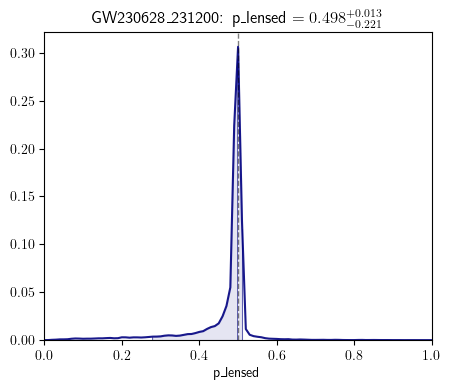

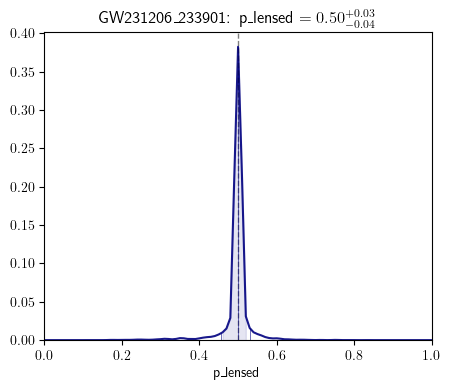

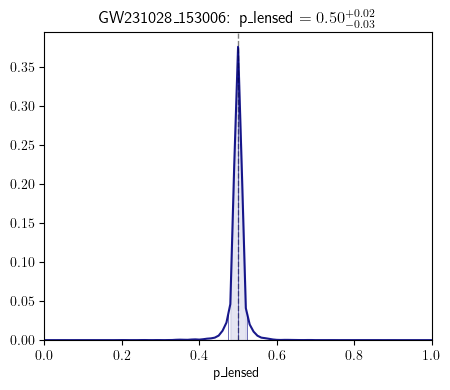

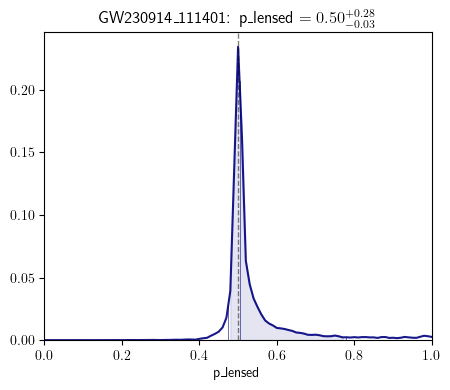

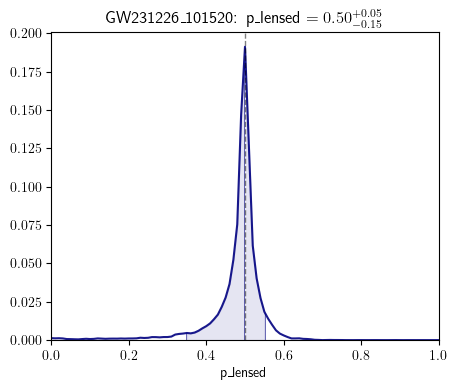

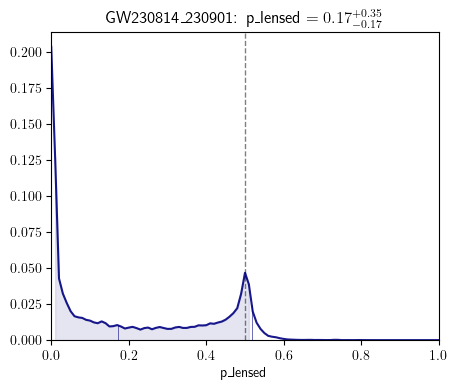

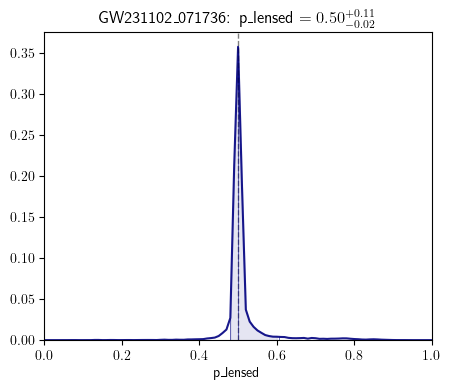

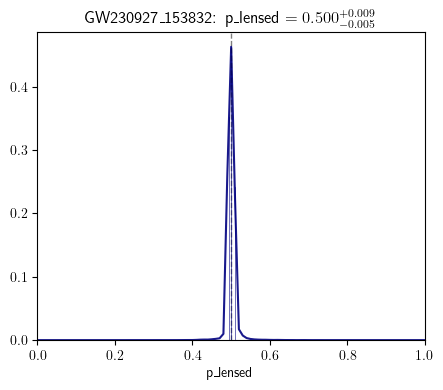

In [9]:
bayes_factors = {}
for (eventname, event_path) in zip(eventname_list, event_dir_list):
    samples, samples_lvk = load_posterior_samples(eventname, event_path)
    if samples is None:
        continue

    # plot the p_lensed distribution
    plot_p_lensed(samples, eventname=eventname)

    # and compute Bayes factor and uncertainty
    bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
    bayes_factors[eventname] = (np.median(bayes_factors_), np.std(bayes_factors_))

In [10]:
for eventname, (median, std) in bayes_factors.items():
    print(f"{eventname}:\t{median:.4f} +- {std:.4f}")

GW230628_231200:	0.8809 +- 0.0023
GW231206_233901:	0.9881 +- 0.0014
GW231028_153006:	0.9971 +- 0.0008
GW230914_111401:	1.1825 +- 0.0050
GW231226_101520:	0.9216 +- 0.0025
GW230814_230901:	0.2892 +- 0.0032
GW231102_071736:	1.0490 +- 0.0025
GW230927_153832:	1.0026 +- 0.0004
